In [1]:
# !uv pip install --system scikit-learn==1.5.2

try:
    from autogluon.tabular import TabularPredictor
except:
    !uv pip install autogluon
    from autogluon.tabular import TabularPredictor

## -- To use Foundtion models: data ~100k rows --
!uv pip install autogluon.tabular[tabarena]

Using Python 3.12.13 environment at: /usr
Resolved 231 packages in 4.86s
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
⠙ Preparing packages... (0/52)
opentelemetry-sdk    ------------------------------     0 B/134.00 KiB
⠙ Preparing packages... (0/52)
opentelemetry-sdk    ------------------------------ 14.75 KiB/134.00 KiB
⠙ Preparing packages... (0/52)
opentelemetry-sdk    ------------------------------ 14.75 KiB/134.00 KiB
⠙ Preparing packages... (0/52)
opentelemetry-sdk    ------------------------------ 14.75 KiB/134.00 KiB
⠙ Preparing packages... (0/52)
pbr                  ------------------------------     0 B/128.81 KiB
opentelemetry-sdk    ------------------------------ 14.75 KiB/134.00 KiB
⠙ Preparing packages... (0/52)
pbr                  ------------------------------ 14.81 KiB/128.81 KiB
opentelemetry-sdk    ------------------------------ 14.75 KiB/134.00 KiB
⠙ Preparing packages... (0/52)
pbr                  ----------------

In [2]:
# %%capture saved_prints
!uv pip install ipywidgets
!apt-get install -qq -y graphviz graphviz-dev && pip install -q pydot
!pip install -qq pygraphviz

Using Python 3.12.13 environment at: /usr
Checked 1 package in 140ms
Selecting previously unselected package libatk1.0-data.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ...
Unpack

In [3]:
import os
import torch
import pydot

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

print("Packages import succesful!")

Packages import succesful!


In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

np.random.seed(CFG['SEED'])
random.seed(CFG['SEED'])

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(orig.head())
orig.info()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [7]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

Total Features: 12


In [8]:
# !rm -r {MODELS_PATH}
!rm -r /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [9]:
MODELS_PATH = "/kaggle/working/AG_models/"
MODELS_PATH

'/kaggle/working/AG_models/'

In [10]:
## -- Train AutoGluon --

predictor = TabularPredictor(
    label = TARGET,
    # problem_type = "regression",
    eval_metric = "roc_auc",
    path = MODELS_PATH,
).fit(
    train_data = orig[FEATURES+[TARGET]],
    presets = "best_quality_v150", # v1_original_best_quality_v150
    auto_stack = False,
    dynamic_stacking = False,
    num_stack_levels = 1,
    num_bag_folds = 5,
    # num_bag_sets = 2,
    # refit_full = True
    time_limit = 3600,
    # ag_args_fit = {'num_cpus': os.cpu_count()},
    verbosity=1,
)

AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])


In [11]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 66
-> Best model   : WeightedEnsemble_L2



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.990008,roc_auc,1.080938,90.533820,0.001290,0.312037,2,True,33
1,WeightedEnsemble_L3,0.989950,roc_auc,4.209807,720.334854,0.001215,0.348277,3,True,66
2,LightGBM_r184_BAG_L1,0.989789,roc_auc,0.920085,9.625272,0.920085,9.625272,1,True,21
3,NeuralNetFastAI_r147_BAG_L2,0.989594,roc_auc,3.889274,687.942567,0.200469,33.475239,2,True,53
4,LightGBM_r46_BAG_L2,0.989546,roc_auc,3.935413,663.162284,0.246608,8.694956,2,True,56
5,CatBoost_c1_BAG_L1,0.989313,roc_auc,0.040087,12.881587,0.040087,12.881587,1,True,1
6,LightGBM_r6_BAG_L1,0.989288,roc_auc,0.372455,7.289487,0.372455,7.289487,1,True,16
7,LightGBM_r163_BAG_L2,0.989269,roc_auc,3.889377,664.156067,0.200572,9.688739,2,True,38
8,LightGBMPrep_r19_BAG_L1,0.989243,roc_auc,0.061394,5.437891,0.061394,5.437891,1,True,26
9,NeuralNetFastAI_r25_BAG_L2,0.989206,roc_auc,3.776643,672.004442,0.087838,17.537114,2,True,39


In [12]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [13]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [14]:
## -- Create folder directory to save predictions --
SAVE_PATH = "/kaggle/working/AG_preds/"
# FILE_NAME = f"ag_{TARGET}_orig.parquet"

!mkdir {SAVE_PATH}

print(f"File path created: {SAVE_PATH}")

File path created: /kaggle/working/AG_preds/


### PREDICTION with BEST MODEL

In [15]:
def make_best_predictions(predictor, df=None, save_path=SAVE_PATH, data_type=None, use_distill=False):
    if use_distill:
        print("Exporting distilled model predictions", end="... ")
        distilled_model_names = predictor.distill()
        # ldr = predictor.leaderboard()
        model_to_deploy = distilled_model_names[0]
        preds = predictor.predict_proba(df, model=model_to_deploy, as_pandas=False, as_multiclass=False)
        fila_name = f"{save_path}ag_distill_{TARGET}_{data_type}.npy"
        np.save(fila_name, preds)
    else:
        print("Exporting best model predictions", end="... ")
        preds = predictor.predict_proba(df, as_pandas=False, as_multiclass=False)
        fila_name = f"{save_path}ag_best_{TARGET}_{data_type}.npy"
        np.save(fila_name, preds)

    print(f"✓ Finished! {len(preds)} samples")
    print(fila_name)

    return preds

In [16]:
%%time

final_oof = make_best_predictions(
    predictor,
    df=orig[FEATURES+[TARGET]],
    save_path=SAVE_PATH,
    data_type="original",
    # use_distill=True,
)
print()
final_oof

Exporting best model predictions... ✓ Finished! 7500 samples
/kaggle/working/AG_preds/ag_best_addicted_label_original.npy

CPU times: user 5.24 s, sys: 55.1 ms, total: 5.3 s
Wall time: 3.06 s


array([0.00519994, 0.04213085, 0.2551345 , ..., 0.99946415, 0.9940791 ,
       0.99999994], dtype=float32)

In [17]:
%%time

final_train = make_best_predictions(
    predictor,
    df=train[FEATURES],
    save_path=SAVE_PATH,
    data_type="train",
    # use_distill=True,
)
print()
final_train

Exporting best model predictions... ✓ Finished! 691369 samples
/kaggle/working/AG_preds/ag_best_addicted_label_train.npy

CPU times: user 6min 28s, sys: 233 ms, total: 6min 28s
Wall time: 3min 17s


array([0.19740659, 0.08931738, 0.00560182, ..., 0.18494725, 0.9983777 ,
       0.01908473], dtype=float32)

In [18]:
%%time

final_test = make_best_predictions(
    predictor,
    df=test[FEATURES],
    save_path=SAVE_PATH,
    data_type="test",
    # use_distill=True,
)
print()
final_test

Exporting best model predictions... ✓ Finished! 296302 samples
/kaggle/working/AG_preds/ag_best_addicted_label_test.npy

CPU times: user 2min 50s, sys: 303 ms, total: 2min 51s
Wall time: 1min 26s


array([0.9966621 , 0.17805053, 0.98995036, ..., 0.00698037, 0.1844228 ,
       0.58881795], dtype=float32)

### MULTI_PREDICTIONS with ALL MODELS

In [19]:
# def make_multi_predictions(predictor, df=None, save_path=SAVE_PATH, data_type=None):
#     print("Exporting multiple model predictions", end="... ")
#     fila_name = f"{save_path}ag_{TARGET}_{data_type}.parquet"
#     preds = predictor.predict_proba_multi(df, as_pandas=False, as_multiclass=False)
#     preds = pd.DataFrame(preds)
#     preds.to_parquet(fila_name, index=False)

#     print(f"✓ Finished! {len(preds)} samples")
#     print(fila_name)

#     return preds

In [20]:
# %%time

# final_oof = make_multi_predictions(
#     predictor,
#     df=orig[FEATURES+[TARGET]],
#     save_path=SAVE_PATH,
#     data_type="original",
# )
# print()
# final_oof

In [21]:
# %%time

# final_train = make_multi_predictions(
#     predictor,
#     df=train[FEATURES],
#     save_path=SAVE_PATH,
#     data_type="train",
# )
# print()
# final_train

In [22]:
# %%time

# final_test = make_multi_predictions(
#     predictor,
#     df=test[FEATURES],
#     save_path=SAVE_PATH,
#     data_type="test",
# )
# print()
# final_test

In [23]:
# %%time

# ## -- TEST PREDICTIONS --
# test_name = f"{SAVE_PATH}test_{FILE_NAME}"
# final_test = pd.DataFrame()

# ag_test_preds = predictor.predict_proba_multi(test[FEATURES][:10_000], as_pandas=False, as_multiclass=False)
# for k, v in tqdm(ag_test_preds.items(), desc="Exporting TEST predictions"):
#     k_renamed = k.replace("_", "")
#     final_test[k_renamed] = v.ravel()

# final_test.to_parquet(test_name, index=False)
# print(f"test predictions saved: {test_name}\n")

# final_test.head()

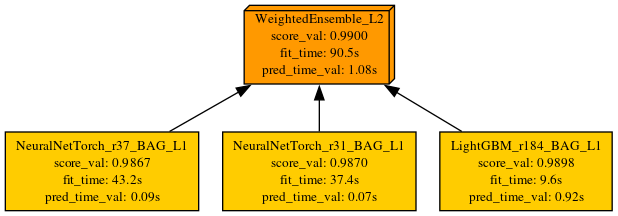

In [24]:
predictor.plot_ensemble_model(filename="ensemble_model.png")
display(Image(f"{MODELS_PATH}ensemble_model.png"))

In [25]:
# import xgboost

# orig[TARGET] = orig[TARGET].map({'Presence': 1, 'Absence': 0})

# model = xgboost.XGBClassifier(random_state=42)
# model.fit(orig[BASE], orig[TARGET])

# display(model)

# train_preds = model.predict_proba(train[BASE].iloc[:100])[:, 1]
# test_preds = model.predict_proba(test[BASE].iloc[:100])[:, 1]

# pd.Series(train_preds).head(), pd.Series(test_preds).head()

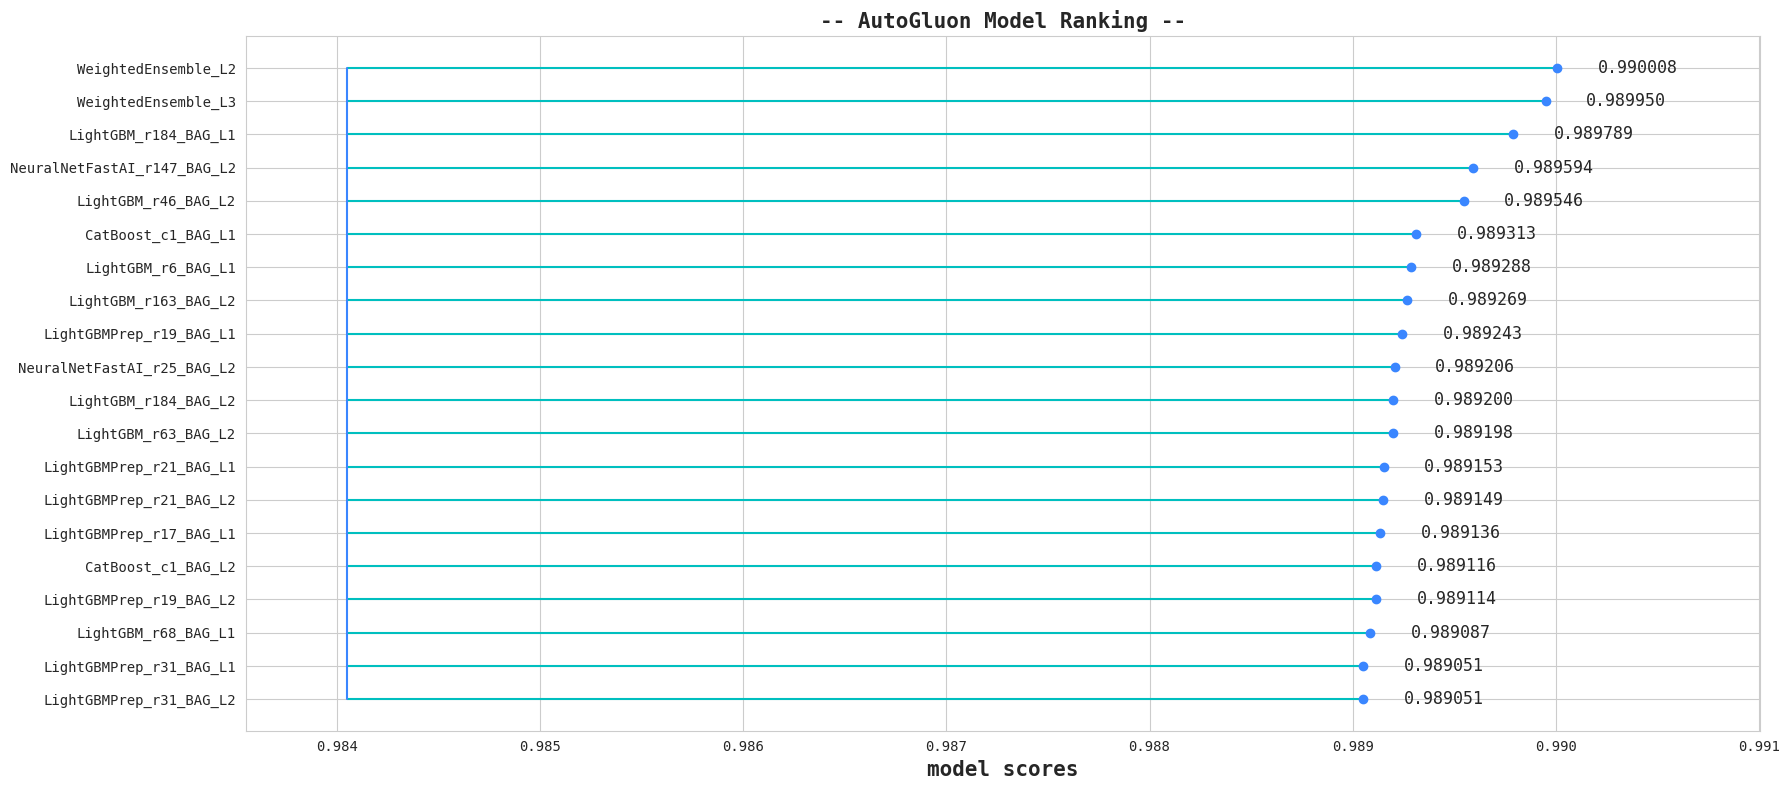

In [26]:
## -- Extract model scores --
# result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(dict(zip(leaderboard['model'], leaderboard['score_val'])), orient='index')\
              .rename(columns={0: 'scores'}).iloc[:20] \
              .sort_values(by='scores')

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 8))
plt.stem(
    result_df.index,
    result_df['scores'],
    orientation = "horizontal",
    bottom = min_score - 0.005,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.0055, max_score + 0.001)
plt.xlabel("model scores", fontdict={'size': 15, "weight": "semibold"})
plt.title("-- AutoGluon Model Ranking --", fontdict={'size': 15, "weight": "semibold"})

for i, value in enumerate(result_df['scores']):
    plt.text(value+2e-4, i, f"{abs(value):.6f}", ha="left", va="center", fontsize=12)

# plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ~ HILLCLIMB

In [27]:
# %%time

# try:
#     from hillclimbers import climb_hill, partial
# except:
#     !uv pip install -q hillclimbers
#     from hillclimbers import climb_hill, partial

# from sklearn.metrics import roc_auc_score

# ## -- Select specific models: Run climber --
# L1_COLS = [c for c in final_train.columns if 'L1' in c]

# for name, df in tqdm([("train", final_train), ("test", final_test)]):
#     print(f"===== Hillclimbing {name.upper()} dataset =====")
#     hc_test, hc_oof = climb_hill(
#             train=orig,
#             target=TARGET,
#             oof_pred_df=final_oof[L1_COLS],
#             test_pred_df=df[L1_COLS],
#             eval_metric=partial(roc_auc_score),
#             objective="maximize",
#             negative_weights=True,
#             return_oof_preds=True,
#             precision=0.01,
#             plot_hill=True,
#             plot_hist=False,
#     )

#     file_save = f"{SAVE_PATH}ag_{name}_hillclimb.npy"
#     # np.save(file_save, hc_oof)
#     np.save(file_save, hc_test)
    
#     score = roc_auc_score(orig[TARGET], hc_oof).round(6)
    
#     print("-"*50)
#     print(f"✅ Score: {score} | {file_save.split("ag_")[1]} saved!!")
#     print("-"*50)
#     print(f"\n\n")

In [28]:
print(f"""
{'-'*47}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE - | {'█'*5}
{'-'*47}
""")


-----------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE - | █████
-----------------------------------------------



In [29]:
## -- Delete stored files --
!rm -r {MODELS_PATH}